# Previsão Meteorológica de Curitiba-PR

Projeto em Python para consulta e análise de dados meteorológicos em tempo real.

O sistema utiliza dados externos para apresentar:
- previsão de temperatura máxima e mínima;
- volume de chuva;
- probabilidade de precipitação;
- resumo automático dos principais eventos da semana;
- gráficos para visualização dos dados.


In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from zoneinfo import ZoneInfo

In [4]:
url = "https://api.open-meteo.com/v1/forecast"

parametros = {
    "latitude": -25.43,
    "longitude": -49.27,
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum,precipitation_probability_max",
    "timezone": "America/Sao_Paulo",
    "forecast_days": 7
}

resposta = requests.get(url, params=parametros)
dados = resposta.json()["daily"]

previsao = pd.DataFrame({
    "Data": dados["time"],
    "Temp_Max": dados["temperature_2m_max"],
    "Temp_Min": dados["temperature_2m_min"],
    "Chuva_mm": dados["precipitation_sum"],
    "Chance_Chuva": dados["precipitation_probability_max"]
})

previsao


,Data,Temp_Max,Temp_Min,Chuva_mm,Chance_Chuva
0,2026-09-28,25.9,13.0,8.3,65
1,2026-09-29,28.4,14.8,8.3,100
2,2026-09-30,26.4,17.1,16.4,96
3,2026-10-01,21.1,11.9,8.9,86
4,2026-10-02,19.4,11.1,0.3,6
5,2026-10-03,20.9,11.5,0.0,18
6,2026-10-04,21.2,14.2,12.0,88


In [5]:
previsao = pd.DataFrame({
    "Data": dados["time"],
    "Temp_Max": dados["temperature_2m_max"],
    "Temp_Min": dados["temperature_2m_min"],
    "Chuva_mm": dados["precipitation_sum"],
    "Chance_Chuva": dados["precipitation_probability_max"]
})

previsao

,Data,Temp_Max,Temp_Min,Chuva_mm,Chance_Chuva
0,2026-09-28,25.9,13.0,8.3,65
1,2026-09-29,28.4,14.8,8.3,100
2,2026-09-30,26.4,17.1,16.4,96
3,2026-10-01,21.1,11.9,8.9,86
4,2026-10-02,19.4,11.1,0.3,6
5,2026-10-03,20.9,11.5,0.0,18
6,2026-10-04,21.2,14.2,12.0,88


In [7]:
print(previsao.columns.tolist())


['Data', 'Temp_Max', 'Temp_Min', 'Chuva_mm', 'Chance_Chuva']


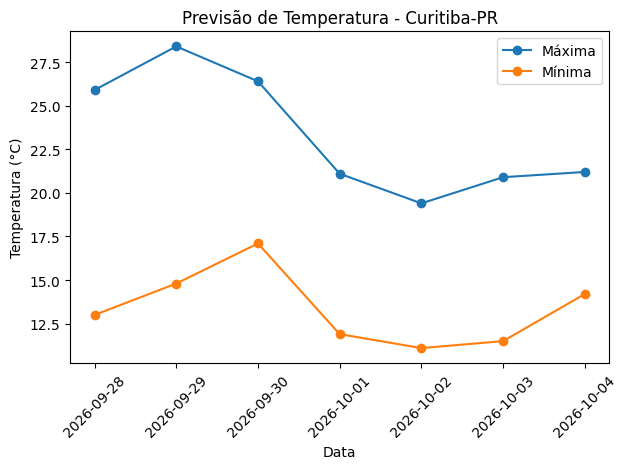

In [8]:
plt.plot(previsao["Data"], previsao["Temp_Max"], marker="o", label="Máxima")
plt.plot(previsao["Data"], previsao["Temp_Min"], marker="o", label="Mínima")

plt.title("Previsão de Temperatura - Curitiba-PR")
plt.xlabel("Data")
plt.ylabel("Temperatura (°C)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()


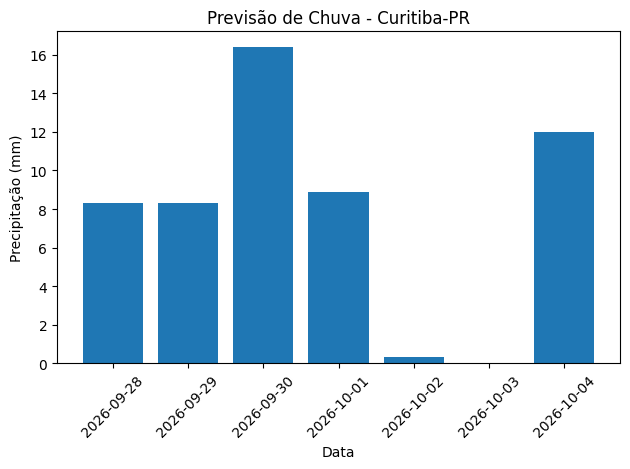

In [9]:
plt.bar(previsao["Data"], previsao["Chuva_mm"])

plt.title("Previsão de Chuva - Curitiba-PR")
plt.xlabel("Data")
plt.ylabel("Precipitação (mm)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


## Sobre o projeto

Este projeto consulta dados meteorológicos reais para Curitiba-PR utilizando a API Open-Meteo.

A aplicação:
- consulta automaticamente a previsão dos próximos 7 dias;
- organiza os dados utilizando Pandas;
- identifica o dia mais quente;
- identifica o maior volume previsto de chuva;
- identifica a maior probabilidade de precipitação;
- realiza uma classificação simples da chance de chuva;
- apresenta gráficos de temperatura e precipitação.

### Tecnologias utilizadas
- Python
- Pandas
- Matplotlib
- Requests
- API Open-Meteo

> A classificação de chance de chuva utilizada no projeto possui finalidade demonstrativa e não representa um alerta meteorológico oficial.